In [ ]:
import torch
from torch import nn
import d2l.torch as d2l
import random

# ========== 超参数设置 ==========
batch_size = 256
num_epochs = 25
lr = 0.5
limit = 2000  # 仅选取2000条训练数据
wd = 1e-3     # 权重衰退大小
dropout = 0.3


train_iter_full, test_iter = d2l.load_data_fashion_mnist(batch_size)

# 修复：先把全部训练数据存入列表，再随机选2000，避免顺序截取类别扎堆
all_data = []
for X, y in train_iter_full:
    for i in range(X.shape[0]):
        all_data.append((X[i], y[i]))

# 随机采样，解决类别集中问题
import random
random.shuffle(all_data)
select_data = all_data[:limit]

small_x = [item[0].unsqueeze(0) for item in select_data]
small_y = [item[1].unsqueeze(0) for item in select_data]

all_X = torch.cat(small_x)
all_y = torch.cat(small_y)
train_iter = d2l.load_array((all_X, all_y), batch_size, is_train=True)


net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256), nn.ReLU(),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 64),  nn.ReLU(),
    nn.Linear(64, 10)
)

def init_weight(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std = 0.01)
net.apply(init_weight)

loss = nn.CrossEntropyLoss()
trainer = torch.optim.SGD(net.parameters(), lr = lr)


KeyboardInterrupt: 

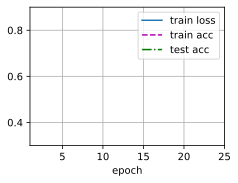

In [14]:
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)